In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))


In [9]:
data = {
    "text": [
        "The team won the championship after a thrilling final match",
        "The striker scored a hat-trick to seal the victory for his club",
        "Our national cricket team lifted the world cup after years of hard work",
        "The coach praised the players for their discipline and teamwork",
        "The tennis player won her third grand slam title this year",
        "The football league announced new fixtures for the upcoming season",
        "The marathon runner broke the national record in the finals",
        "The basketball team is preparing for the playoffs next month",

        "The new smartphone features a faster processor and better camera",
        "Artificial intelligence is transforming how software is developed",
        "The company launched a new laptop with improved battery life",
        "Researchers built a machine learning model to detect spam emails",
        "The startup released an app that uses natural language processing",
        "Cloud computing is reducing the cost of running large applications",
        "Engineers unveiled a robot capable of performing complex tasks",
        "The tech giant announced a major update to its operating system",

        "The senator proposed a new bill to reform healthcare policy",
        "Elections are scheduled to take place early next year",
        "The president addressed the nation regarding new economic reforms",
        "Parliament passed a law increasing the minimum wage",
        "The government announced new tax policies for small businesses",
        "The opposition party criticized the budget presented by the minister",
        "Voters lined up early to cast their ballots in the general election",
        "The prime minister met world leaders to discuss trade agreements",
    ],
    "label": [
        "Sports", "Sports", "Sports", "Sports", "Sports", "Sports", "Sports", "Sports",
        "Technology", "Technology", "Technology", "Technology", "Technology", "Technology", "Technology", "Technology",
        "Politics", "Politics", "Politics", "Politics", "Politics", "Politics", "Politics", "Politics",
    ]
}

df = pd.DataFrame(data)
df.head()


,text,label
0,The team won the championship after a thrillin...,Sports
1,The striker scored a hat-trick to seal the vic...,Sports
2,Our national cricket team lifted the world cup...,Sports
3,The coach praised the players for their discip...,Sports
4,The tennis player won her third grand slam tit...,Sports


In [10]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
df[['text', 'clean_text']].head()


,text,clean_text
0,The team won the championship after a thrillin...,team championship thrilling final match
1,The striker scored a hat-trick to seal the vic...,striker scored hat trick seal victory club
2,Our national cricket team lifted the world cup...,national cricket team lifted world cup years h...
3,The coach praised the players for their discip...,coach praised players discipline teamwork
4,The tennis player won her third grand slam tit...,tennis player third grand slam title year


In [11]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.3, random_state=42, stratify=df['label']
)

count_vec = CountVectorizer()
X_train_bow = count_vec.fit_transform(X_train_text)
X_test_bow = count_vec.transform(X_test_text)

print("Vocabulary size:", len(count_vec.vocabulary_))
print("Train samples:", X_train_bow.shape[0], "| Test samples:", X_test_bow.shape[0])


Vocabulary size: 101
Train samples: 16 | Test samples: 8


In [12]:
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_bow, y_train)

y_pred = nb_model.predict(X_test_bow)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))


Accuracy: 0.125

              precision    recall  f1-score   support

    Politics       0.17      0.50      0.25         2
      Sports       0.00      0.00      0.00         3
  Technology       0.00      0.00      0.00         3

    accuracy                           0.12         8
   macro avg       0.06      0.17      0.08         8
weighted avg       0.04      0.12      0.06         8



/home/jo/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jo/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jo/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


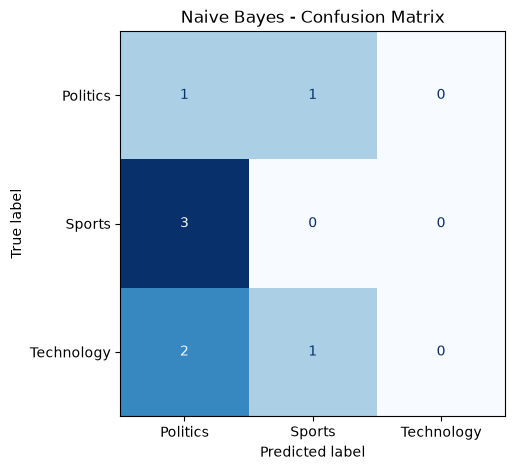

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Naive Bayes - Confusion Matrix")
plt.show()


In [14]:
new_samples = [
    "The government passed a new law on data privacy",
    "The goalkeeper made an incredible save in the last minute",
    "The new AI chip speeds up model training significantly",
]

clean_samples = [preprocess_text(s) for s in new_samples]
sample_features = count_vec.transform(clean_samples)
predictions = nb_model.predict(sample_features)

for sentence, pred in zip(new_samples, predictions):
    print(f"'{sentence}'  ->  {pred}")


'The government passed a new law on data privacy'  ->  Politics
'The goalkeeper made an incredible save in the last minute'  ->  Politics
'The new AI chip speeds up model training significantly'  ->  Technology
